# YOLOv8 Segmentation


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import json
from tqdm import tqdm
import shutil
import zipfile
import os


In [ ]:

def extract_dataset():
    """Разархивирование sign_dataset.zip если он существует"""
    zip_path = Path('/content/sample_data/sign_dataset.zip')
    extract_path = Path('sign_dataset')

    if zip_path.exists():
        print(f"📦 Найден архив: {zip_path}")
        print(f"📂 Разархивирование в {extract_path}...")

        # Удаляем старую директорию если есть
        if extract_path.exists():
            shutil.rmtree(extract_path)

        # Разархивируем
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')

        return True

VIA_TRAIN = Path('sign_dataset/train/via_region_data.json')
VIA_VAL = Path('sign_dataset/val/via_region_data.json')
IMG_TRAIN = Path('sign_dataset/train')
IMG_VAL = Path('sign_dataset/val')

YOLO_DIR = Path('dataset_yolo')
YOLO_TRAIN = YOLO_DIR / 'train'
YOLO_VAL = YOLO_DIR / 'val'


def via_to_mask(entry, img_shape):
    h, w = img_shape
    mask = np.zeros((h, w), dtype=np.uint8)

    regions = entry.get('regions', {})

    for idx, (region_id, region) in enumerate(regions.items()):
        shape_attrs = region.get('shape_attributes', {})

        if shape_attrs.get('name') == 'polygon':
            points_x = shape_attrs['all_points_x']
            points_y = shape_attrs['all_points_y']

            points = np.array(list(zip(points_x, points_y)), dtype=np.int32)

            cv2.fillPoly(mask, [points], idx + 1)

    return mask


def mask_to_yolo_polygons(mask, object_id):
    binary_mask = (mask == object_id).astype(np.uint8)

    if binary_mask.sum() == 0:
        return []

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    h, w = mask.shape
    polygons = []

    for contour in contours:
        if len(contour) < 3:
            continue

        epsilon = 0.005 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        polygon = [0]

        for point in approx:
            px, py = point[0]
            polygon.extend([px / w, py / h])

        polygons.append(polygon)

    return polygons


def process_split(via_path, img_dir, out_dir, split_name):
    with open(via_path, 'r') as f:
        via_data = json.load(f)

    print(f"\nОбработка {split_name}: {len(via_data)} изображений")

    out_img_dir = out_dir / 'images'
    out_label_dir = out_dir / 'labels'

    processed = 0

    for via_key in tqdm(via_data.keys(), desc=split_name):
        entry = via_data[via_key]
        filename = entry['filename']

        img_path = img_dir / filename

        if not img_path.exists():
            print(f"\nПропуск: {filename} не найден")
            continue

        shutil.copy2(img_path, out_img_dir / filename)

        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]

        mask = via_to_mask(entry, (h, w))

        all_polygons = []
        unique_objects = np.unique(mask)[1:]

        for obj_id in unique_objects:
            polygons = mask_to_yolo_polygons(mask, obj_id)
            all_polygons.extend(polygons)

        label_path = out_label_dir / f"{Path(filename).stem}.txt"
        with open(label_path, 'w') as f:
            for polygon in all_polygons:
                line = ' '.join(map(str, polygon))
                f.write(line + '\n')

        processed += 1

    print(f"{split_name}: обработано {processed} изображений")
    return processed


def create_data_yaml():
    yaml_content = f"""path: {YOLO_DIR.absolute()}
train: train/images
val: val/images

# Для сегментации (все знаки - один класс)
nc: 1
names:
0: road sign
"""

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

train_count = process_split(VIA_TRAIN, IMG_TRAIN, YOLO_TRAIN, 'train')

val_count = process_split(VIA_VAL, IMG_VAL, YOLO_VAL, 'val')

create_data_yaml()

print("Итого:")
print(f"  Train: {train_count} изображений")
print(f"  Val: {val_count} изображений")
print(f"  Датасет сохранен в: {YOLO_DIR}")



Конвертация VIA → YOLO Segmentation
📦 Найден архив: /content/sample_data/sign_dataset.zip
📂 Разархивирование в sign_dataset...
✅ Разархивировано!
Создана структура в dataset_yolo

Обработка train: 2054 изображений


train: 100%|██████████| 2054/2054 [01:11<00:00, 28.53it/s]


train: обработано 2054 изображений

Обработка val: 127 изображений


val: 100%|██████████| 127/127 [00:06<00:00, 18.21it/s]

val: обработано 127 изображений

✅ Создан dataset_yolo/data.yaml
Контент:
path: /content/dataset_yolo
train: train/images
val: val/images

# Для сегментации (все знаки - один класс)
nc: 1
names:
  0: road sign


Итого:
  Train: 2054 изображений
  Val: 127 изображений
  Датасет сохранен в: dataset_yolo


## 1. Импорты и проверка датасета

In [ ]:
DATASET_DIR = Path('/content/dataset_yolo')

yaml_path = DATASET_DIR / 'data.yaml'
if yaml_path.exists():
    with open(yaml_path) as f:
        print(f.read())

Датасет готов к обучению:
  Train images: 2054
  Train labels: 2054
  Val images: 127
  Val labels: 127

✅ data.yaml найден
path: /content/dataset_yolo
train: train/images
val: val/images

# Для сегментации (все знаки - один класс)
nc: 1
names:
  0: road sign



## 2. Визуализация примеров сегментации

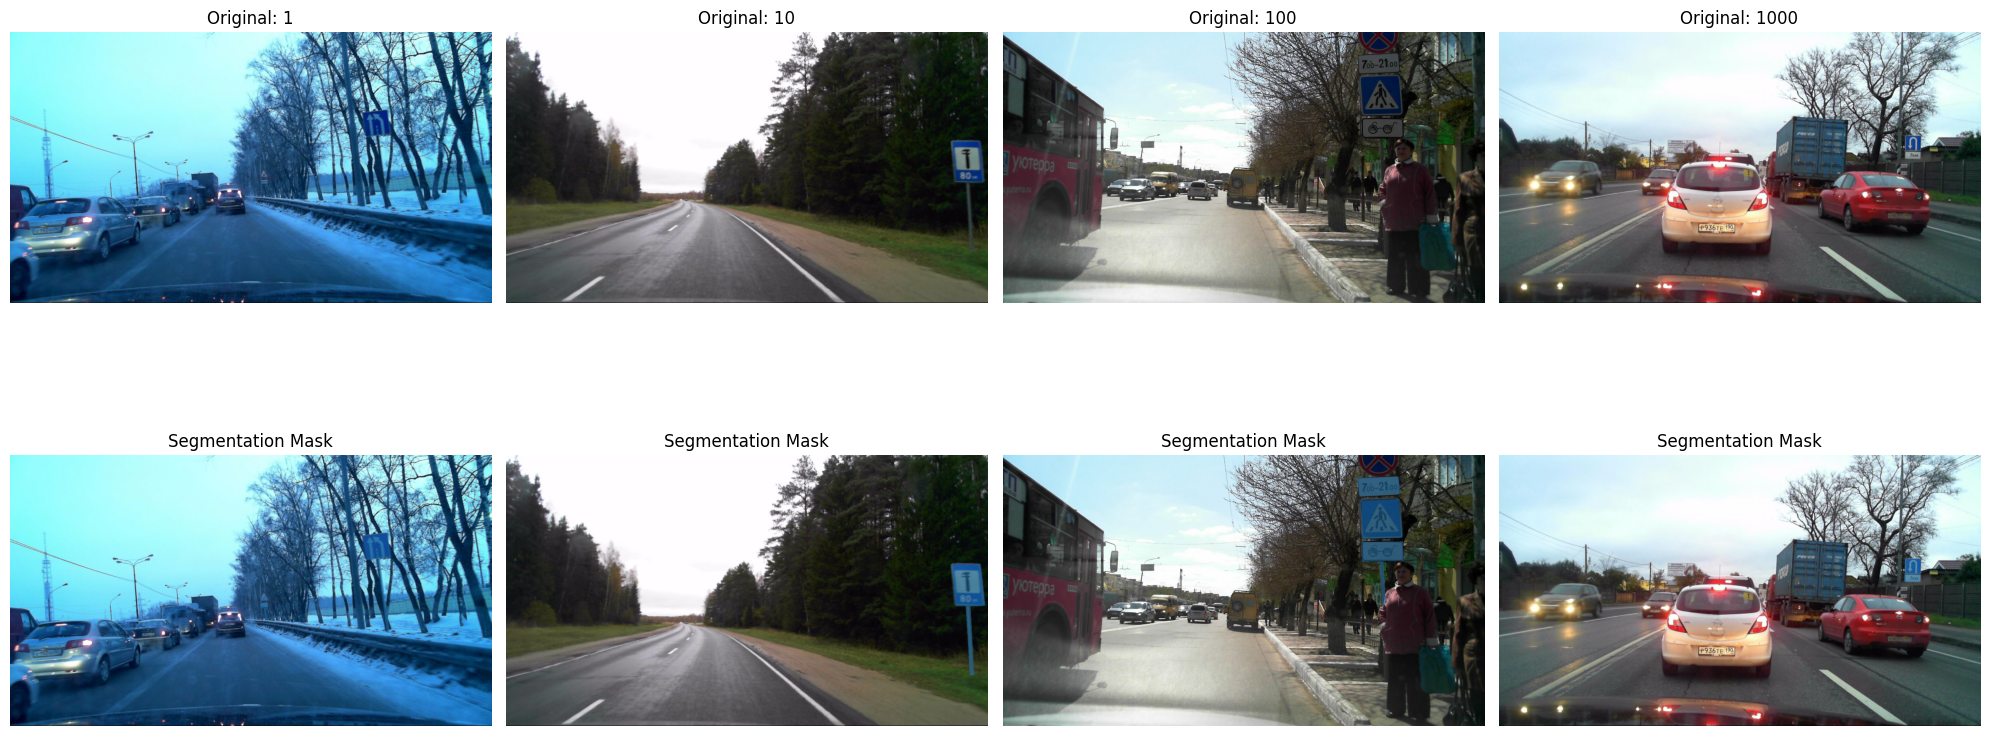

✅ Примеры сохранены в yolo_seg_examples.png


In [ ]:
def visualize_yolo_annotation(img_path, label_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    overlay = img.copy().astype(float)

    with open(label_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) < 5:
                continue

            class_id = int(parts[0])
            points = np.array(parts[1:]).reshape(-1, 2)
            points[:, 0] *= w
            points[:, 1] *= h
            points = points.astype(np.int32)

            color = plt.cm.tab10(class_id)[:3]
            color = (np.array(color) * 255)

            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(mask, [points], 1)
            overlay[mask > 0] = overlay[mask > 0] * 0.5 + color * 0.5

            cv2.polylines(overlay.astype(np.uint8), [points], True, color, 2)

    return img, overlay.astype(np.uint8)


img_files = sorted(list((DATASET_DIR / 'train' / 'images').glob('*.jpg')))[:4]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, img_path in enumerate(img_files):
    label_path = DATASET_DIR / 'train' / 'labels' / f'{img_path.stem}.txt'

    img, overlay = visualize_yolo_annotation(img_path, label_path)

    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f'Original: {img_path.stem}')
    axes[0, idx].axis('off')

    axes[1, idx].imshow(overlay)
    axes[1, idx].set_title('Segmentation Mask')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig('yolo_seg_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Обучение YOLOv8

In [ ]:
model = YOLO('yolov8m-seg.pt')

✅ Модель yolov8m-seg.pt загружена


In [ ]:
results = model.train(
    data=str(DATASET_DIR / 'data.yaml'),
    epochs=10,
    imgsz=640,
    batch=8,
    project='models',
    name='via_road_signs_seg',
    exist_ok=True,
    patience=10,
    save=True,
    device=0,
    verbose=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=via_road_signs_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

## 4. Валидация

In [ ]:
best_model = YOLO('/content/runs/segment/models/via_road_signs_seg/weights/best.pt')

metrics = best_model.val(
    data=str(DATASET_DIR / 'data.yaml'),
    split='val'
)

print('\n📊 Результаты валидации:')
print(f"  mAP50 (box): {metrics.box.map50:.4f}")
print(f"  mAP50-95 (box): {metrics.box.map:.4f}")
if hasattr(metrics, 'seg'):
    print(f"  mAP50 (seg): {metrics.seg.map50:.4f}")
    print(f"  mAP50-95 (seg): {metrics.seg.map:.4f}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2175.3±1144.8 MB/s, size: 100.4 KB)
val: Scanning /content/dataset_yolo/val/labels.cache... 127 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 44.4Mit/s 0.0s
val: /content/dataset_yolo/val/images/207.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/211.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/213.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/214.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/216.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/223.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/225.jpg: corrupt JPEG restored and saved
val: /content/dataset_yolo/val/images/231.jpg: corru

## 5. Расчет метрик IoU, Precision, Recall

In [ ]:
import pandas as pd

def calculate_metrics(model, split='val'):

    img_dir = DATASET_DIR / split / 'images'
    label_dir = DATASET_DIR / split / 'labels'

    image_files = sorted(list(img_dir.glob('*.jpg')))
    print(f'Расчет метрик для {len(image_files)} изображений...')

    results = []

    for img_path in tqdm(image_files, desc='Processing'):
        label_path = label_dir / f'{img_path.stem}.txt'

        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Ground truth маска
        gt_mask = np.zeros((h, w), dtype=np.uint8)
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.strip().split()))
                    if len(parts) < 5:
                        continue
                    points = np.array(parts[1:]).reshape(-1, 2)
                    points[:, 0] *= w
                    points[:, 1] *= h
                    points = points.astype(np.int32)
                    cv2.fillPoly(gt_mask, [points], 1)

        pred = model(img_rgb, verbose=False)

        pred_mask = np.zeros((h, w), dtype=np.uint8)
        if len(pred) > 0 and pred[0].masks is not None:
            masks = pred[0].masks.data.cpu().numpy()
            for mask in masks:
                mask_resized = cv2.resize(mask.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
                pred_mask[mask_resized > 0] = 1

        # IoU
        intersection = np.logical_and(pred_mask, gt_mask).sum()
        union = np.logical_or(pred_mask, gt_mask).sum()
        iou = intersection / union if union > 0 else 0

        # Precision/Recall
        tp = intersection
        fp = (pred_mask > 0).sum() - intersection
        fn = (gt_mask > 0).sum() - intersection
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'image': img_path.name,
            'iou': iou,
            'precision': precision,
            'recall': recall
        })

    df = pd.DataFrame(results)

    summary = {
        'mean_iou': df['iou'].mean(),
        'std_iou': df['iou'].std(),
        'mean_precision': df['precision'].mean(),
        'mean_recall': df['recall'].mean(),
        'IoU>=0.5': (df['iou'] >= 0.5).sum() / len(df) * 100,
        'IoU>=0.75': (df['iou'] >= 0.75).sum() / len(df) * 100,
        'IoU>=0.9': (df['iou'] >= 0.9).sum() / len(df) * 100,
    }

    return df, summary


df, summary = calculate_metrics(best_model, split='val')

for k, v in summary.items():
    print(f'{k:20s}: {v:.4f}')

Path('results').mkdir(exist_ok=True)
df.to_csv('results/metrics_val.csv', index=False)
pd.DataFrame([summary]).to_csv('results/summary_val.csv', index=False)

Расчет метрик для 127 изображений...


Processing: 100%|██████████| 127/127 [00:06<00:00, 19.07it/s]


📊 МЕТРИКИ СЕГМЕНТАЦИИ
mean_iou            : 0.3407
std_iou             : 0.2438
mean_precision      : 0.4589
mean_recall         : 0.5208
IoU>=0.5            : 29.1339
IoU>=0.75           : 1.5748
IoU>=0.9            : 0.0000

💾 Сохранено в results/


## 6. Тестирование на своих фото

Найдено 1 фото


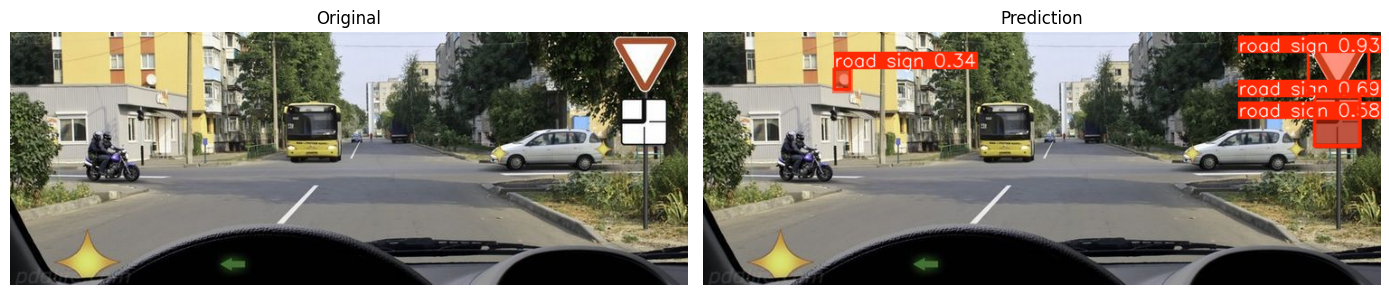


💾 Результаты сохранены в results/


In [ ]:
CUSTOM_DIR = Path('/content/custom_test_images')
CUSTOM_DIR.mkdir(exist_ok=True)

custom_images = list(CUSTOM_DIR.glob('*.jpg')) + list(CUSTOM_DIR.glob('*.png'))

for img_path in custom_images:
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = best_model(img_rgb, verbose=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')

    if len(results) > 0 and results[0].masks is not None:
        seg_img = results[0].plot()
        axes[1].imshow(seg_img)
    else:
        axes[1].imshow(img_rgb)
    axes[1].set_title('Prediction')
    axes[1].axis('off')


    plt.tight_layout()
    plt.savefig(f'results/{img_path.stem}_pred.png', dpi=150)
    plt.show()
